# Dataset 2: NSL-KDD Network Intrusion Detection — Anomaly Classification
## MSc Data Analytics — Data Mining & Machine Learning Portfolio
### National College of Ireland | CRISP-DM Methodology

**Dataset:** NSL-KDD Network Intrusion Detection Dataset (Kaggle)  
**Records:** 22,544 | **Features:** 41  
**Task:** Binary Classification — Normal vs Anomaly (Attack)  
**Algorithms:** Decision Tree Classifier & Neural Network (MLP)  
**Metrics:** Accuracy, Precision, Recall, F1-Score, ROC-AUC  

**V2X Context:** Vehicular Ad-hoc Networks (VANETs) are a foundational layer of V2X infrastructure. Network-level anomalies such as DoS, Probe, R2L, and U2R attacks directly threaten V2X communication integrity. This study applies ML-based Intrusion Detection System (IDS) techniques — benchmarked on the NSL-KDD dataset — to classify network traffic as normal or malicious, supporting secure connected vehicle deployments in V2X environments.

---
## Phase 1 — Business Understanding (CRISP-DM)

**Objective:** Classify network connection records as Normal or Anomaly (Attack) in real-time.

- **Problem type:** Binary Classification
- **Target variable:** `class` — `normal` (0) vs `anomaly` (1)
- **Dataset source:** NSL-KDD — improved version of the KDD Cup 1999 dataset
- **Use case:** Embedded IDS in V2X Roadside Units (RSUs) and OnBoard Units (OBUs) to detect malicious network traffic in real time
- **Methodology:** CRISP-DM (Cross-Industry Standard Process for Data Mining)
- **Why NSL-KDD:** Removes duplicate records from KDD'99, provides balanced train/test splits, and is the standard benchmark for IDS research

---
## Phase 2 — Data Understanding
### 2.1 Import Libraries

In [1]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay, roc_curve, auc
)
from sklearn.inspection import permutation_importance
from statsmodels.stats.contingency_tables import mcnemar

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print("Import Successful")

Import Successful


### 2.2 Load & Inspect Dataset

In [2]:
# Load dataset
df = pd.read_csv('csv_result-KDDTest.csv')

# Clean column names(remove surrounding quotes)
df.columns = [c.strip("'") for c in df.columns]

print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nTarget distribution:')
print(df['class'].value_counts())
print('\nMissing values:', df.isnull().sum().sum())
print('\nData types:')
print(df.dtypes)
df.head()

Shape: (22544, 43)

Columns: ['id', 'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'class']

Target distribution:
class
anomaly    12833
normal      9711
Name: count, dtype: int64

Missing values: 0

Data types:
id                               int64
duration                         int64
protocol_type                

,id,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,1,0,tcp,private,REJ,0,0,0,0,0,...,10,0.04,0.06,0.00,0.00,0.0,0.0,1.00,1.00,anomaly
1,2,0,tcp,private,REJ,0,0,0,0,0,...,1,0.00,0.06,0.00,0.00,0.0,0.0,1.00,1.00,anomaly
2,3,2,tcp,ftp_data,SF,12983,0,0,0,0,...,86,0.61,0.04,0.61,0.02,0.0,0.0,0.00,0.00,normal
3,4,0,icmp,eco_i,SF,20,0,0,0,0,...,57,1.00,0.00,1.00,0.28,0.0,0.0,0.00,0.00,anomaly
4,5,1,tcp,telnet,RSTO,0,15,0,0,0,...,86,0.31,0.17,0.03,0.02,0.0,0.0,0.83,0.71,anomaly


### 2.3 Target Variable — Class Distribution

Class Distribution:
class
anomaly    12833
normal      9711
Name: count, dtype: int64

Balance: 43.1% Normal | 56.9% Anomaly


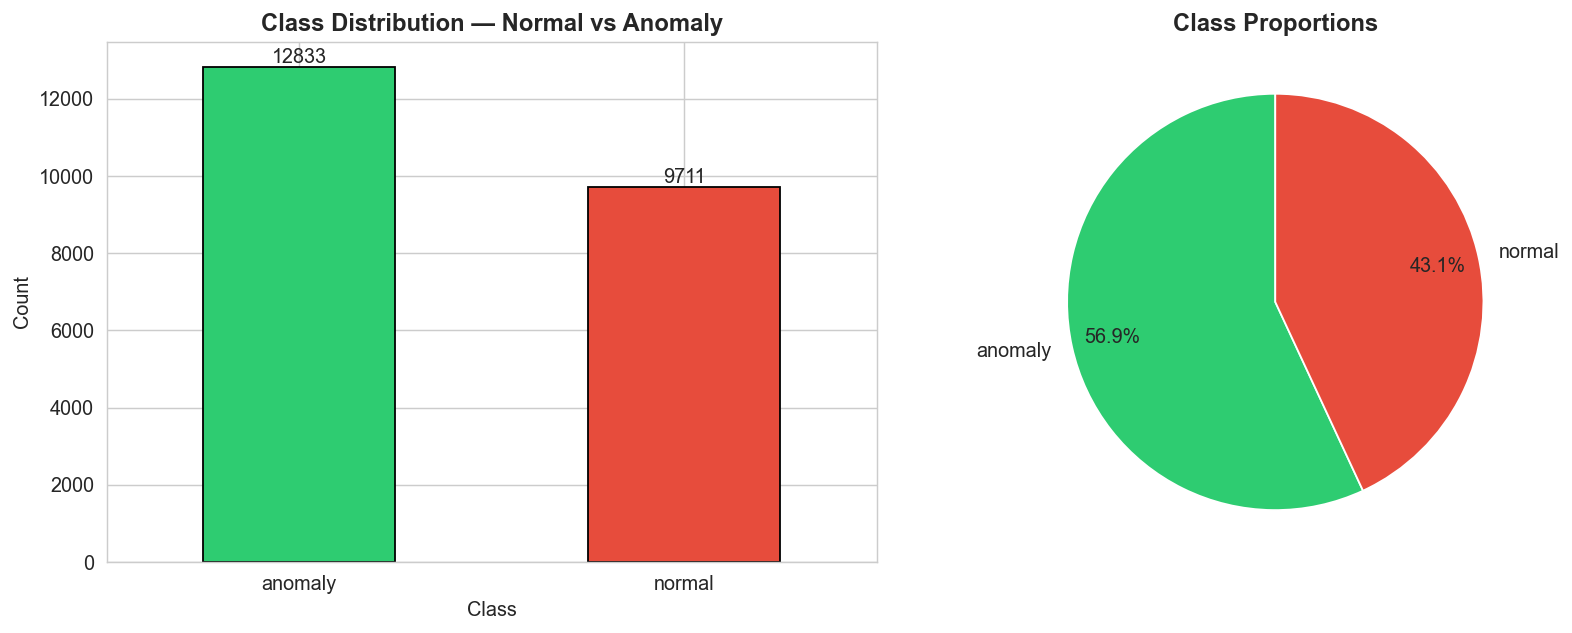

In [3]:
#Target Variable — Class Distribution
vc = df['class'].value_counts()
print('Class Distribution:')
print(vc)
print(f'\nBalance: {vc["normal"]/len(df)*100:.1f}% Normal | {vc["anomaly"]/len(df)*100:.1f}% Anomaly')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
vc.plot(kind='bar', ax=axes[0], color=['#2ecc71','#e74c3c'], edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution — Normal vs Anomaly', fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(str(int(p.get_height())),
                     (p.get_x()+p.get_width()/2, p.get_height()+100), ha='center')

# Pie chart
axes[1].pie(vc.values, labels=vc.index, autopct='%1.1f%%',
            colors=['#2ecc71','#e74c3c'], startangle=90, pctdistance=0.8)
axes[1].set_title('Class Proportions', fontweight='bold')

plt.tight_layout()
plt.savefig('kdd_class_distribution.png', bbox_inches='tight')
plt.show()

### 2.4 Exploratory Data Analysis (EDA) — Key Features

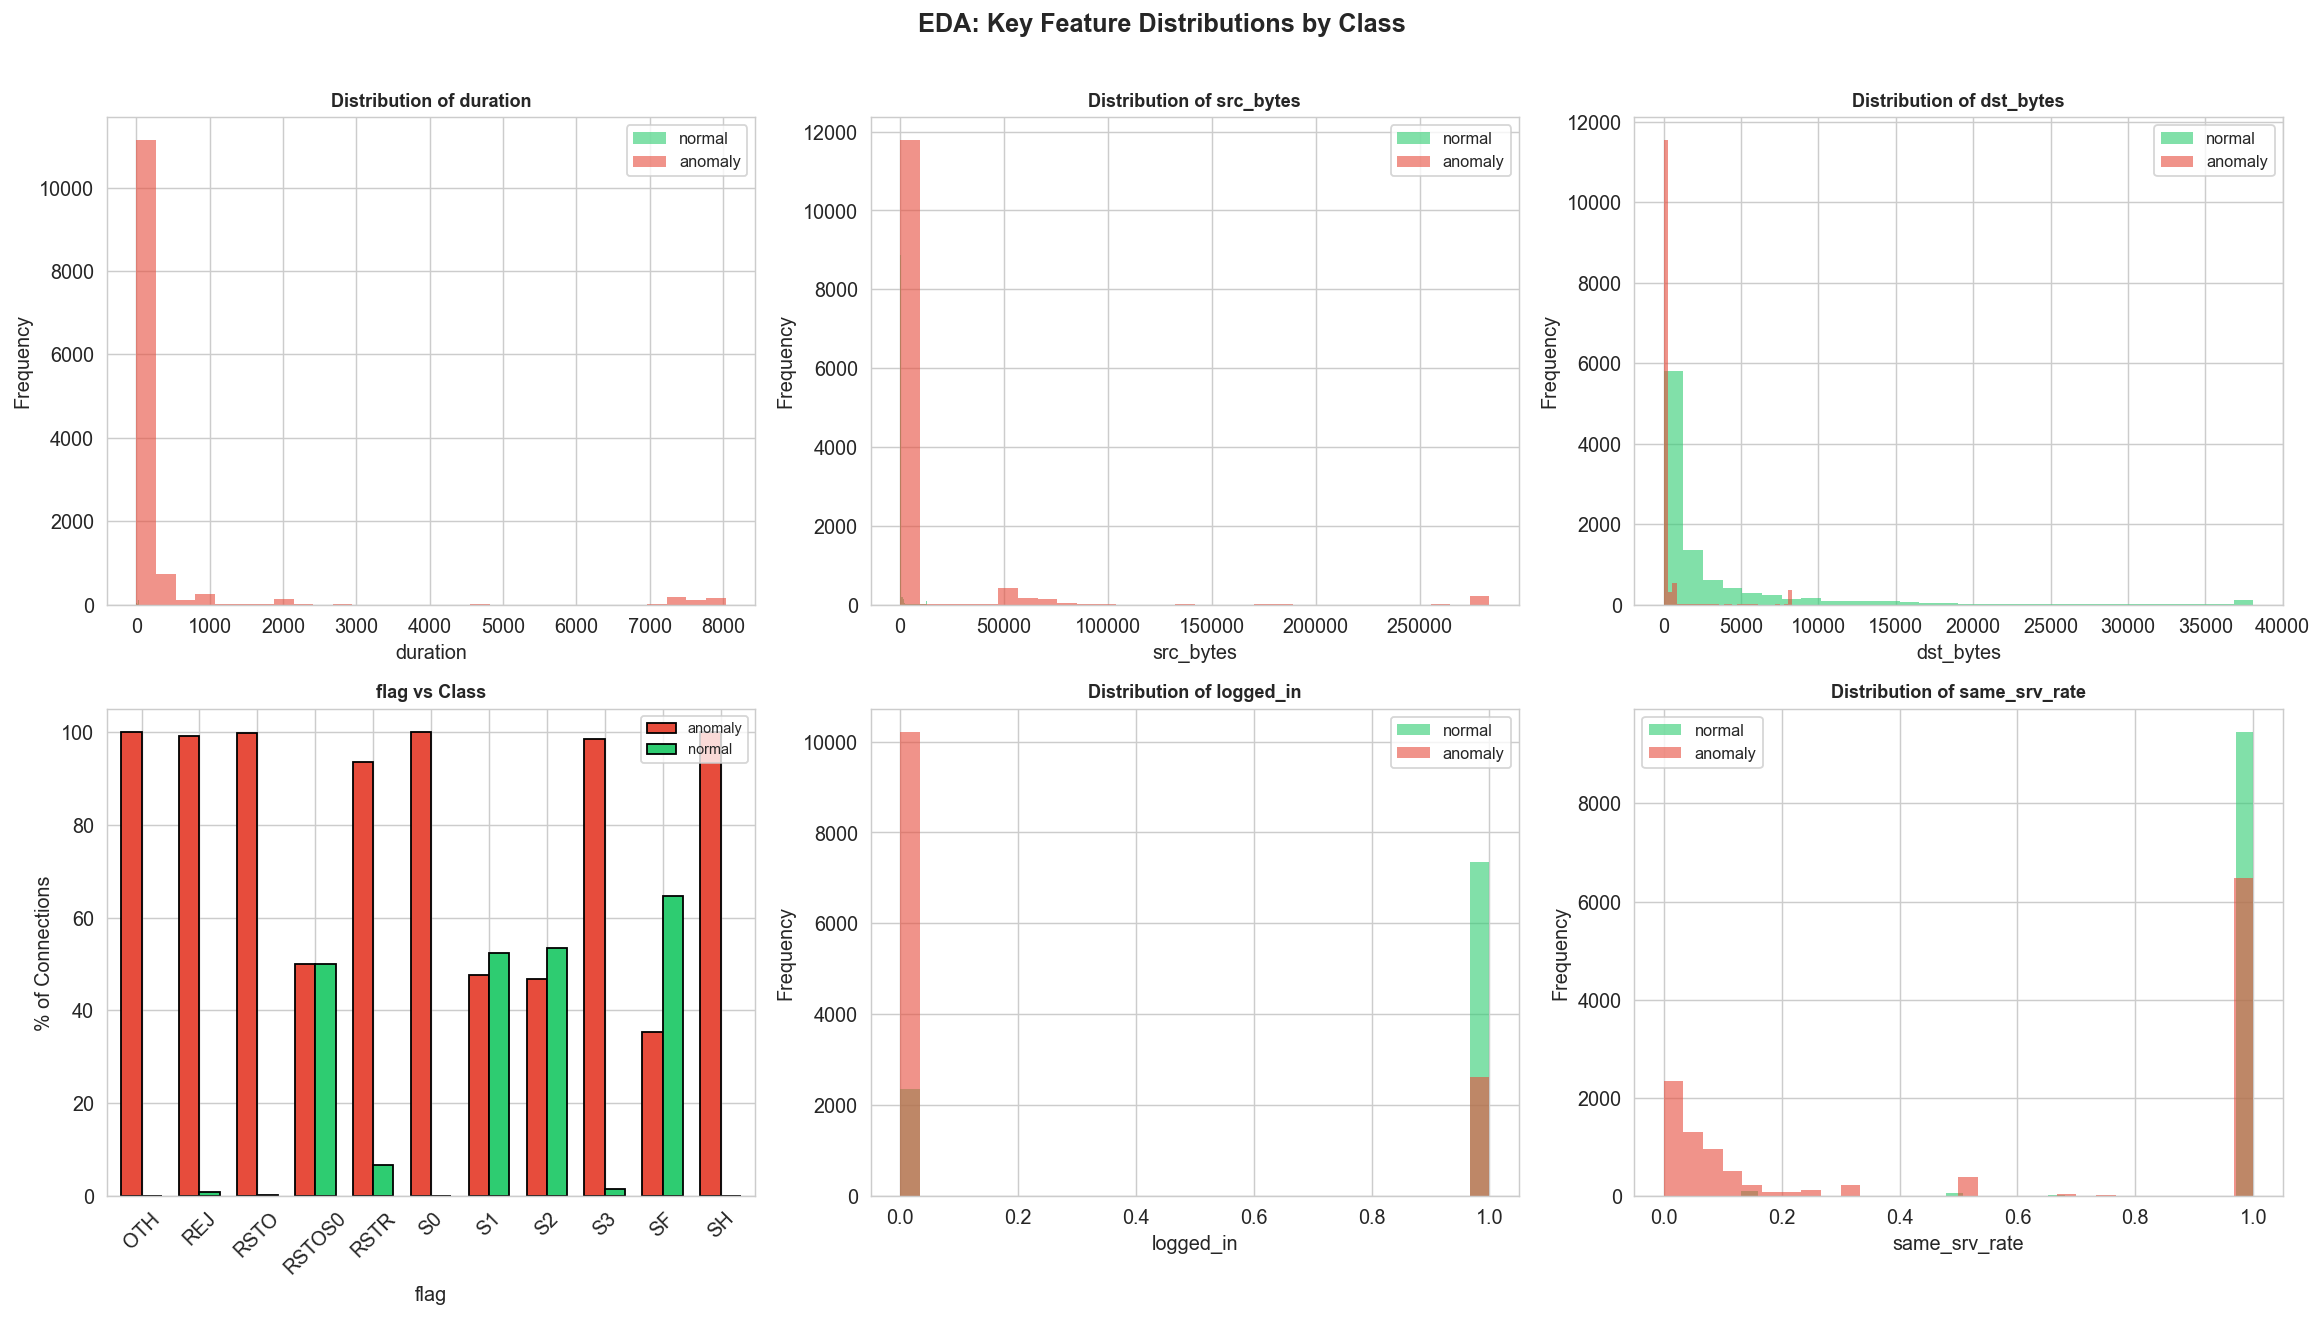

In [4]:
# Exploratory Data Analysis (EDA) 
key_features = ['duration','src_bytes','dst_bytes','flag',
                'logged_in','same_srv_rate']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, feat in zip(axes.flatten(), key_features):
    if df[feat].dtype == 'object':
        ct = pd.crosstab(df[feat], df['class'], normalize='index') * 100
        ct.plot(kind='bar', ax=ax, color=['#e74c3c','#2ecc71'], edgecolor='black', width=0.7)
        ax.set_title(f'{feat} vs Class', fontweight='bold', fontsize=10)
        ax.set_ylabel('% of Connections')
        ax.tick_params(axis='x', rotation=45)
        ax.legend(fontsize=8)
    else:
        for cls, col in [('normal','#2ecc71'), ('anomaly','#e74c3c')]:
            vals = df[df['class']==cls][feat]
            vals_clipped = np.clip(vals, vals.quantile(0.01), vals.quantile(0.99))
            ax.hist(vals_clipped, bins=30, alpha=0.6, color=col, label=cls, edgecolor='none')
        ax.set_title(f'Distribution of {feat}', fontweight='bold', fontsize=10)
        ax.set_xlabel(feat)
        ax.set_ylabel('Frequency')
        ax.legend(fontsize=9)

plt.suptitle('EDA: Key Feature Distributions by Class', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('kdd_eda.png', bbox_inches='tight')
plt.show()

### 2.5 Top Feature Correlations with Target

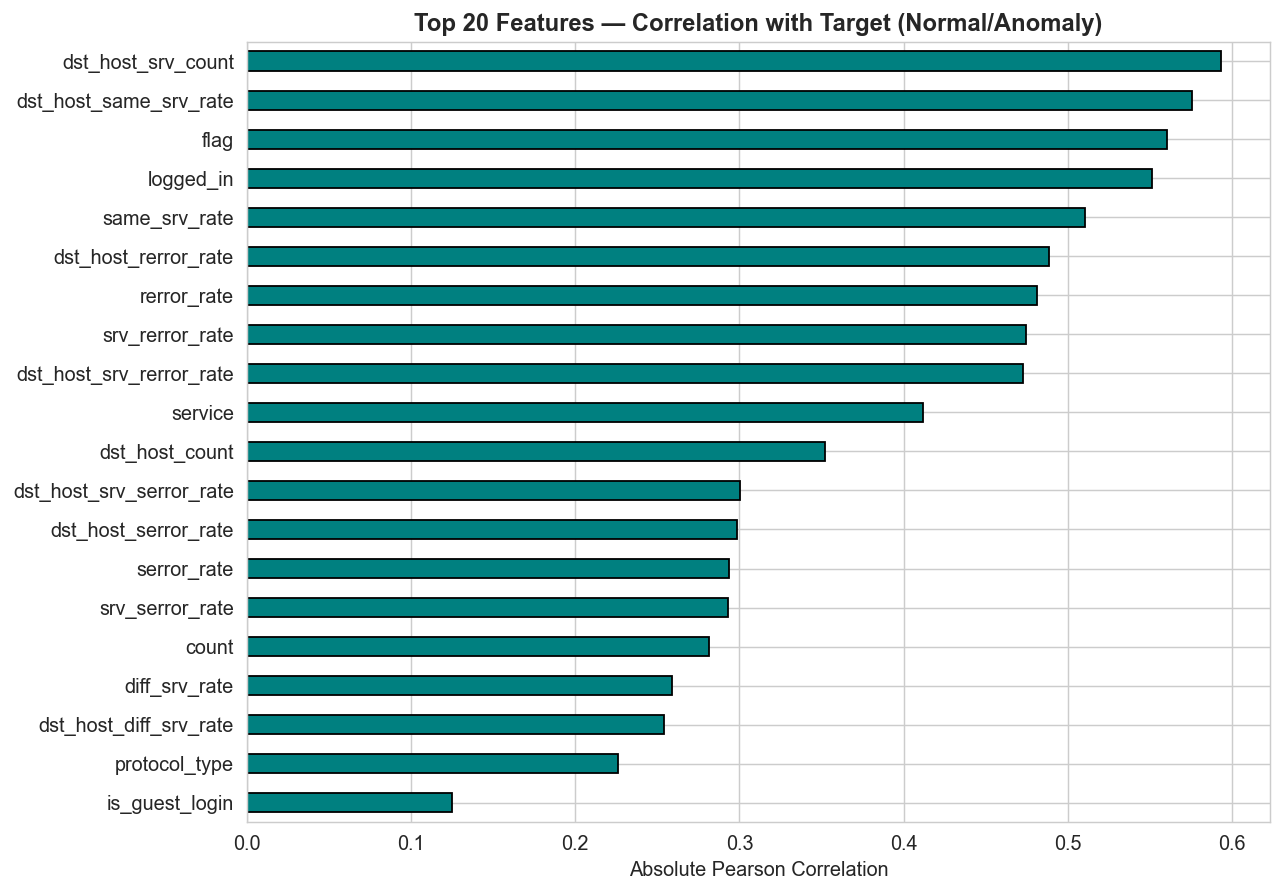

Top 10 features by correlation:
dst_host_srv_count          0.593344
dst_host_same_srv_rate      0.575526
flag                        0.560327
logged_in                   0.551159
same_srv_rate               0.510634
dst_host_rerror_rate        0.488187
rerror_rate                 0.481080
srv_rerror_rate             0.474547
dst_host_srv_rerror_rate    0.472645
service                     0.411802
dtype: float64


In [5]:
# Encode for correlation
df_enc = df.copy()
df_enc['label'] = (df_enc['class'] == 'anomaly').astype(int)
for col in df_enc.select_dtypes(include='object').columns:
    df_enc[col] = LabelEncoder().fit_transform(df_enc[col].astype(str))

X_corr = df_enc.drop(columns=['class','label','id'], errors='ignore')
corr = X_corr.corrwith(df_enc['label']).abs().sort_values(ascending=False)

plt.figure(figsize=(10, 7))
corr.head(20).plot(kind='barh', color='teal', edgecolor='black')
plt.title('Top 20 Features — Correlation with Target (Normal/Anomaly)', fontweight='bold')
plt.xlabel('Absolute Pearson Correlation')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('kdd_feature_correlation.png', bbox_inches='tight')
plt.show()

print('Top 10 features by correlation:')
print(corr.head(10))

---
## Phase 3 — Data Preparation (CRISP-DM)
### 3.1 Preprocessing & Feature Engineering

In [6]:
#Preprocessing & Feature Engineering
data = df.copy()
data.columns = [c.strip("'") for c in data.columns]

# Drop id column
data.drop(columns=['id'], inplace=True, errors='ignore')

# Binary target encoding
data['label'] = (data['class'] == 'anomaly').astype(int)
data.drop(columns=['class'], inplace=True)

# Encode categorical features
le_dict = {}
for col in data.select_dtypes(include='object').columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))
    le_dict[col] = le

# Handle missing values if any
for col in data.columns:
    if data[col].isnull().sum() > 0:
        data[col].fillna(data[col].median(), inplace=True)

X = data.drop(columns=['label'])
y = data['label']

print('Preprocessing complete.')
print(f'Features : {X.shape[1]}')
print(f'Samples  : {X.shape[0]}')
print(f'Target   : Normal={int((y==0).sum())} | Anomaly={int((y==1).sum())}')

Preprocessing complete.
Features : 41
Samples  : 22544
Target   : Normal=9711 | Anomaly=12833


### 3.2 Feature Scaling & Train-Test Split

In [7]:
#Feature Scaling & Train-Test Split
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f'Training set : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Test set     : {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)')
print(f'\nTrain class balance: Normal={int((y_train==0).sum())} | Anomaly={int((y_train==1).sum())}')
print(f'Test  class balance: Normal={int((y_test==0).sum())}  | Anomaly={int((y_test==1).sum())}')

Training set : 18035 samples (80.0%)
Test set     : 4509 samples (20.0%)

Train class balance: Normal=7769 | Anomaly=10266
Test  class balance: Normal=1942  | Anomaly=2567


---
## Phase 4 — Modelling (CRISP-DM)
### Experiment 1: Decision Tree Classifier

In [8]:
# Model 1: Decision Tree — Hyperparameter Tuning via GridSearchCV
dt_params = {
    'max_depth'        : [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'criterion'        : ['gini', 'entropy'],
    'class_weight'     : [None, 'balanced']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params, cv=cv, scoring='f1', n_jobs=-1, verbose=1)
dt_grid.fit(X_train, y_train)

print('Best DT Parameters:', dt_grid.best_params_)
print('Best CV F1 Score  :', round(dt_grid.best_score_, 4))
dt_best = dt_grid.best_estimator_

Fitting 5 folds for each of 180 candidates, totalling 900 fits
Best DT Parameters: {'class_weight': None, 'criterion': 'gini', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV F1 Score  : 0.9864


### Decision Tree — Evaluation Metrics

In [9]:
#Decision Tree — Evaluation Metrics
y_pred_dt = dt_best.predict(X_test)
y_prob_dt = dt_best.predict_proba(X_test)[:, 1]

acc_dt  = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt, zero_division=0)
rec_dt  = recall_score(y_test, y_pred_dt, zero_division=0)
f1_dt   = f1_score(y_test, y_pred_dt, zero_division=0)
auc_dt  = roc_auc_score(y_test, y_prob_dt)

# 5-Fold CV
cv_f1_dt = cross_val_score(dt_best, X_scaled, y, cv=cv, scoring='f1')

print('Decision Tree Results:')
print(f'Accuracy  : {acc_dt:.4f}')
print(f'Precision : {prec_dt:.4f}')
print(f'Recall    : {rec_dt:.4f}')
print(f'F1-Score  : {f1_dt:.4f}')
print(f'ROC-AUC   : {auc_dt:.4f}')
print(f'CV F1     : {cv_f1_dt.mean():.4f} ± {cv_f1_dt.std():.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_dt, target_names=['Normal','Anomaly']))

Decision Tree Results:
Accuracy  : 0.9834
Precision : 0.9871
Recall    : 0.9836
F1-Score  : 0.9854
ROC-AUC   : 0.9873
CV F1     : 0.9862 ± 0.0011

Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98      1942
     Anomaly       0.99      0.98      0.99      2567

    accuracy                           0.98      4509
   macro avg       0.98      0.98      0.98      4509
weighted avg       0.98      0.98      0.98      4509



### Decision Tree — Confusion Matrix & Tree Visualisation

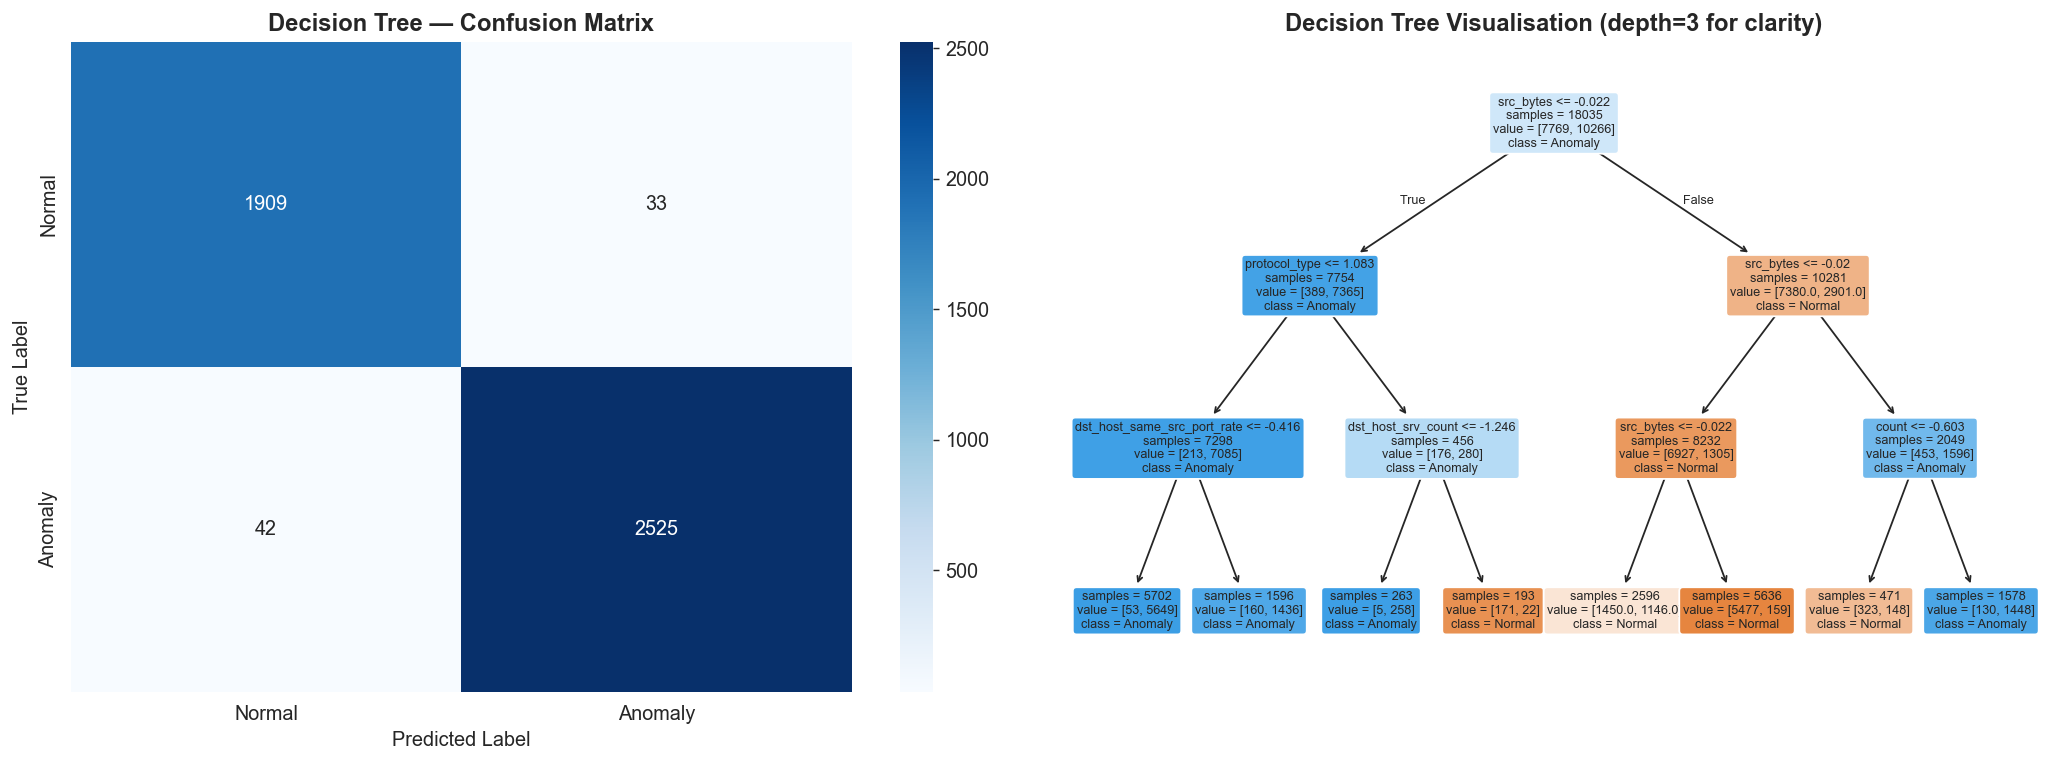

In [10]:
#Decision Tree — Confusion Matrix and Tree Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal','Anomaly'],
            yticklabels=['Normal','Anomaly'])
axes[0].set_title('Decision Tree — Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Simplified tree for readability
dt_vis = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_vis.fit(X_train, y_train)
plot_tree(dt_vis, ax=axes[1],
          feature_names=X.columns.tolist(),
          class_names=['Normal','Anomaly'],
          filled=True, rounded=True, fontsize=7, impurity=False)
axes[1].set_title('Decision Tree Visualisation (depth=3 for clarity)', fontweight='bold')

plt.tight_layout()
plt.savefig('dt_confusion_tree.png', bbox_inches='tight')
plt.show()

### Decision Tree — ROC Curve

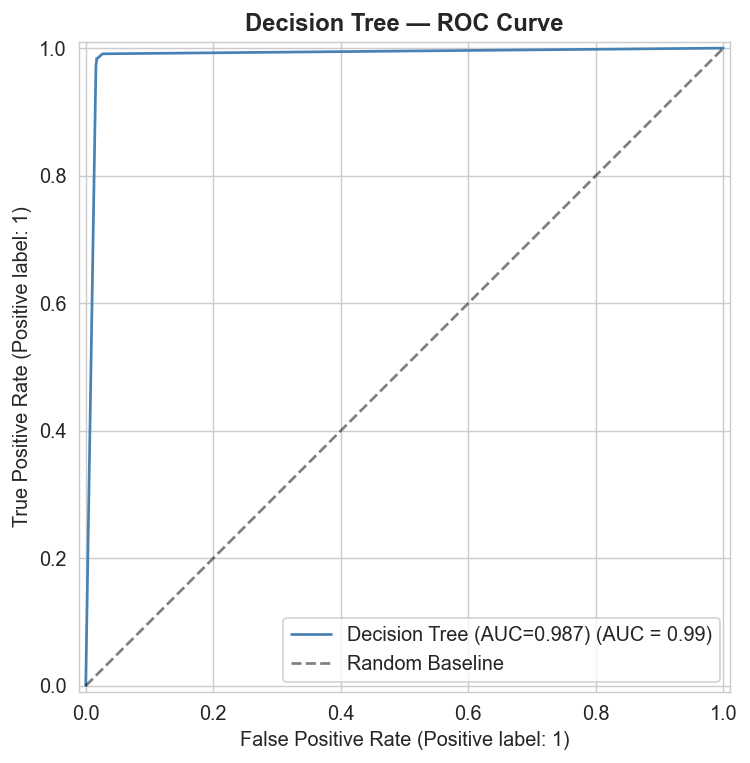

In [11]:
#Decision Tree — ROC Curve
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_prob_dt, ax=ax,
    name=f'Decision Tree (AUC={auc_dt:.3f})', color='steelblue')
ax.plot([0,1],[0,1],'k--', alpha=0.5, label='Random Baseline')
ax.set_title('Decision Tree — ROC Curve', fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('dt_roc.png', bbox_inches='tight')
plt.show()

### Decision Tree — Feature Importance

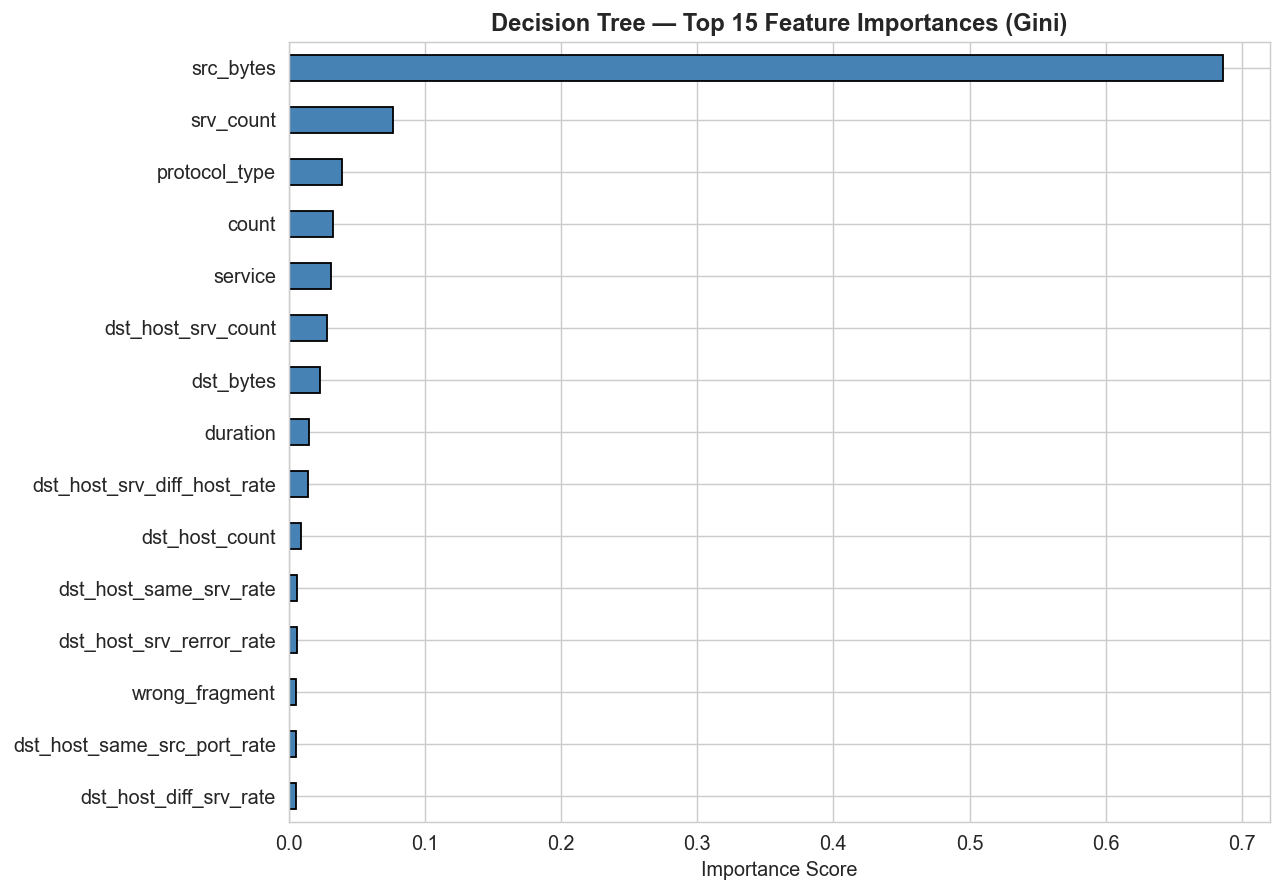

In [12]:
#Decision Tree — Feature Importance
importances_dt = pd.Series(dt_best.feature_importances_,
                            index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 7))
importances_dt.head(15).plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Decision Tree — Top 15 Feature Importances (Gini)', fontweight='bold')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('dt_feature_importance.png', bbox_inches='tight')
plt.show()

---
### Experiment 2: Neural Network (MLP — Multi-Layer Perceptron)

In [13]:
#Model 2: Neural Network MLP(Multi-Layer Perceptron) — Hyperparameter Tuning
mlp_params = {
    'hidden_layer_sizes': [(64, 32), (128, 64), (128, 64, 32), (256, 128, 64)],
    'activation'        : ['relu', 'tanh'],
    'alpha'             : [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01],
    'max_iter'          : [300]
}

mlp_grid = GridSearchCV(
    MLPClassifier(random_state=42, early_stopping=True,
                  n_iter_no_change=15, solver='adam'),
    mlp_params, cv=cv, scoring='f1', n_jobs=-1, verbose=1)
mlp_grid.fit(X_train, y_train)

print('Best MLP Parameters:', mlp_grid.best_params_)
print('Best CV F1 Score   :', round(mlp_grid.best_score_, 4))
mlp_best = mlp_grid.best_estimator_

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best MLP Parameters: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (256, 128, 64), 'learning_rate_init': 0.001, 'max_iter': 300}
Best CV F1 Score   : 0.9783


### Neural Network — Evaluation Metrics

In [14]:
#Neural Network — Evaluation Metrics

y_pred_mlp = mlp_best.predict(X_test)
y_prob_mlp = mlp_best.predict_proba(X_test)[:, 1]

acc_mlp  = accuracy_score(y_test, y_pred_mlp)
prec_mlp = precision_score(y_test, y_pred_mlp, zero_division=0)
rec_mlp  = recall_score(y_test, y_pred_mlp, zero_division=0)
f1_mlp   = f1_score(y_test, y_pred_mlp, zero_division=0)
auc_mlp  = roc_auc_score(y_test, y_prob_mlp)

cv_f1_mlp = cross_val_score(mlp_best, X_scaled, y, cv=cv, scoring='f1')

print('Neural Network (MLP) Results')
print(f'Accuracy  : {acc_mlp:.4f}')
print(f'Precision : {prec_mlp:.4f}')
print(f'Recall    : {rec_mlp:.4f}')
print(f'F1-Score  : {f1_mlp:.4f}')
print(f'ROC-AUC   : {auc_mlp:.4f}')
print(f'CV F1     : {cv_f1_mlp.mean():.4f} ± {cv_f1_mlp.std():.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_mlp, target_names=['Normal','Anomaly']))

Neural Network (MLP) Results
Accuracy  : 0.9794
Precision : 0.9758
Recall    : 0.9883
F1-Score  : 0.9820
ROC-AUC   : 0.9973
CV F1     : 0.9789 ± 0.0012

Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      0.97      0.98      1942
     Anomaly       0.98      0.99      0.98      2567

    accuracy                           0.98      4509
   macro avg       0.98      0.98      0.98      4509
weighted avg       0.98      0.98      0.98      4509



### Neural Network — Confusion Matrix & Training Loss Curve

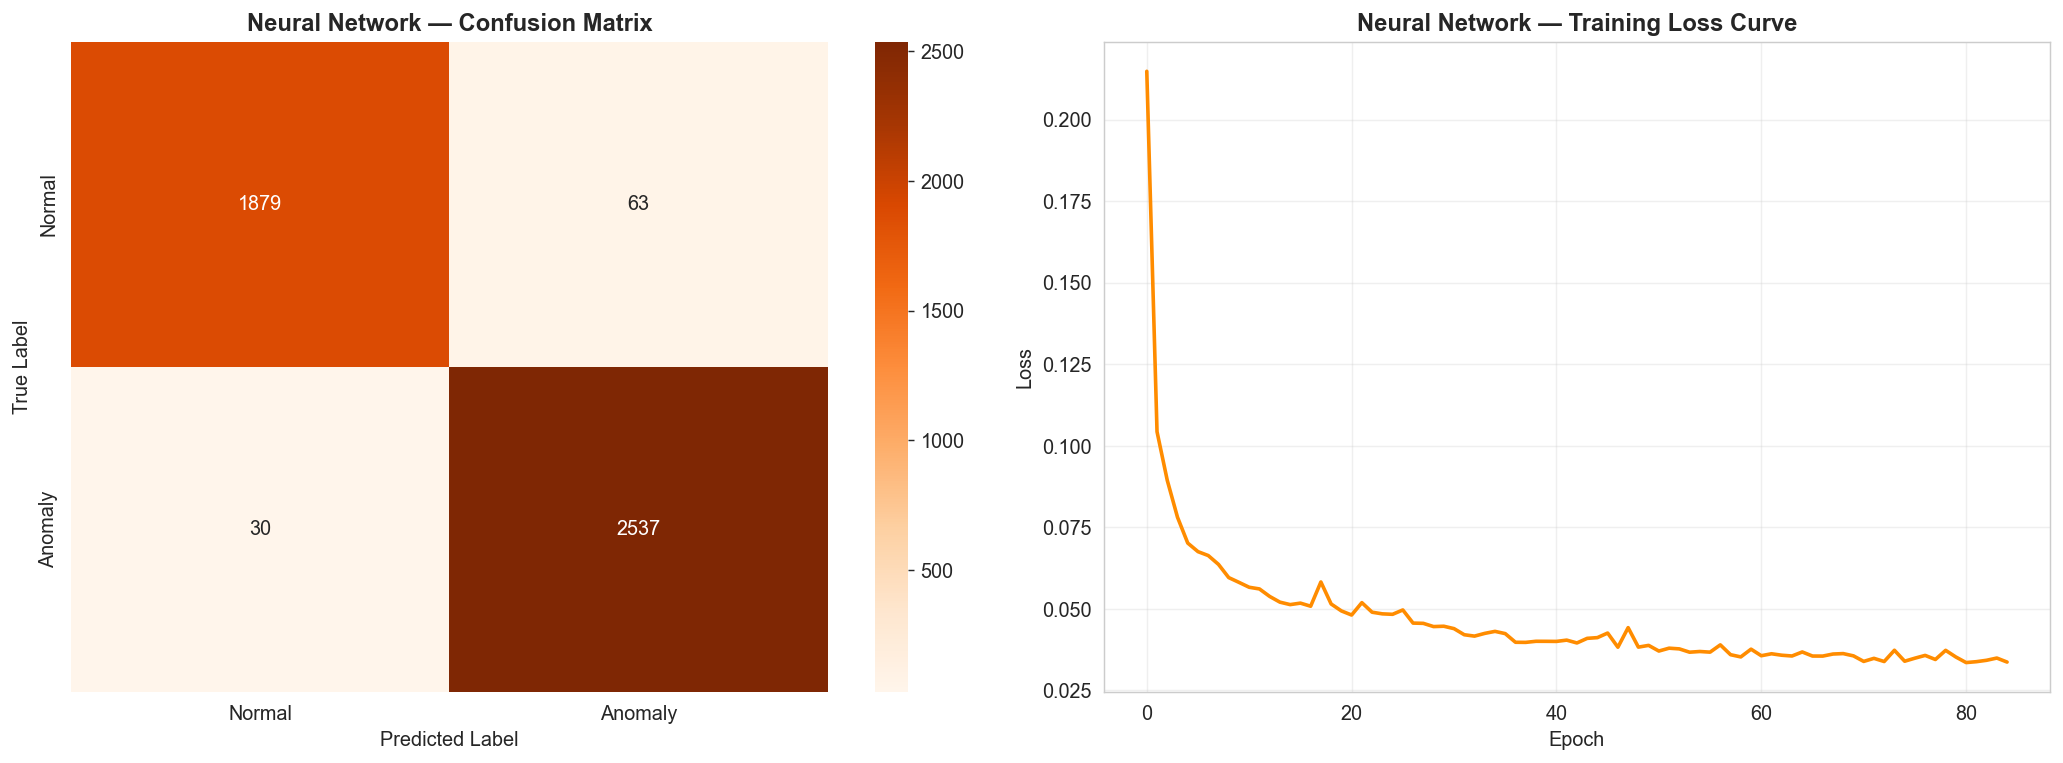

In [15]:
#Neural Network — Confusion Matrix and Training Loss Curve 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_mlp = confusion_matrix(y_test, y_pred_mlp)
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=['Normal','Anomaly'],
            yticklabels=['Normal','Anomaly'])
axes[0].set_title('Neural Network — Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

axes[1].plot(mlp_best.loss_curve_, color='darkorange', linewidth=2)
axes[1].set_title('Neural Network — Training Loss Curve', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mlp_confusion_loss.png', bbox_inches='tight')
plt.show()

### Combined ROC Curve — DT vs MLP

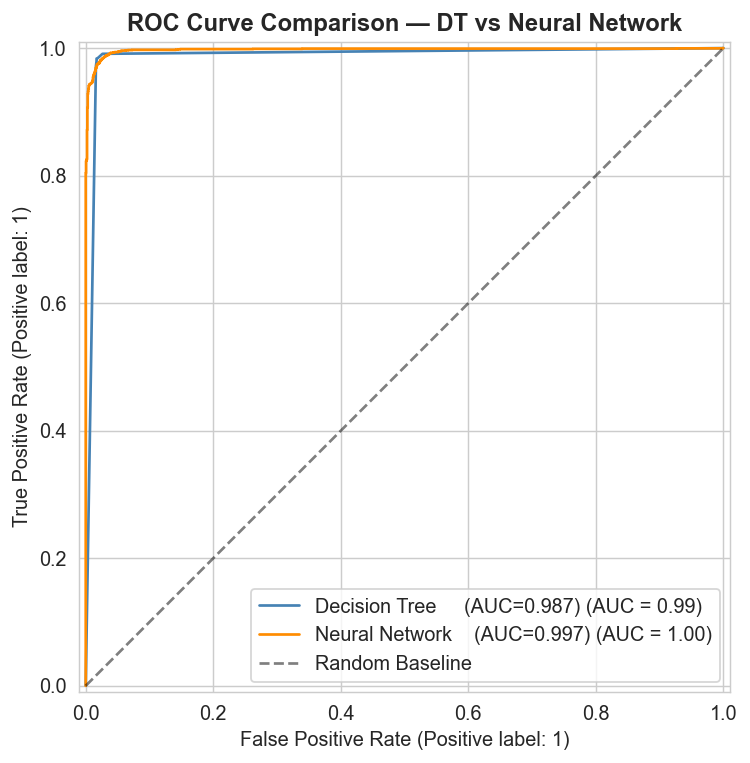

In [16]:
#Combined ROC Curve — DT vs MLP
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_prob_dt,  ax=ax,
    name=f'Decision Tree     (AUC={auc_dt:.3f})',  color='steelblue')
RocCurveDisplay.from_predictions(y_test, y_prob_mlp, ax=ax,
    name=f'Neural Network    (AUC={auc_mlp:.3f})', color='darkorange')
ax.plot([0,1],[0,1],'k--', alpha=0.5, label='Random Baseline')
ax.set_title('ROC Curve Comparison — DT vs Neural Network', fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('roc_comparison.png', bbox_inches='tight')
plt.show()

---
## Phase 5 — Evaluation (CRISP-DM)
### Model Performance Comparison

Performance Comparison Table:
               Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC  CV F1
       Decision Tree    0.9834     0.9871  0.9836    0.9854   0.9873 0.9862
Neural Network (MLP)    0.9794     0.9758  0.9883    0.9820   0.9973 0.9789


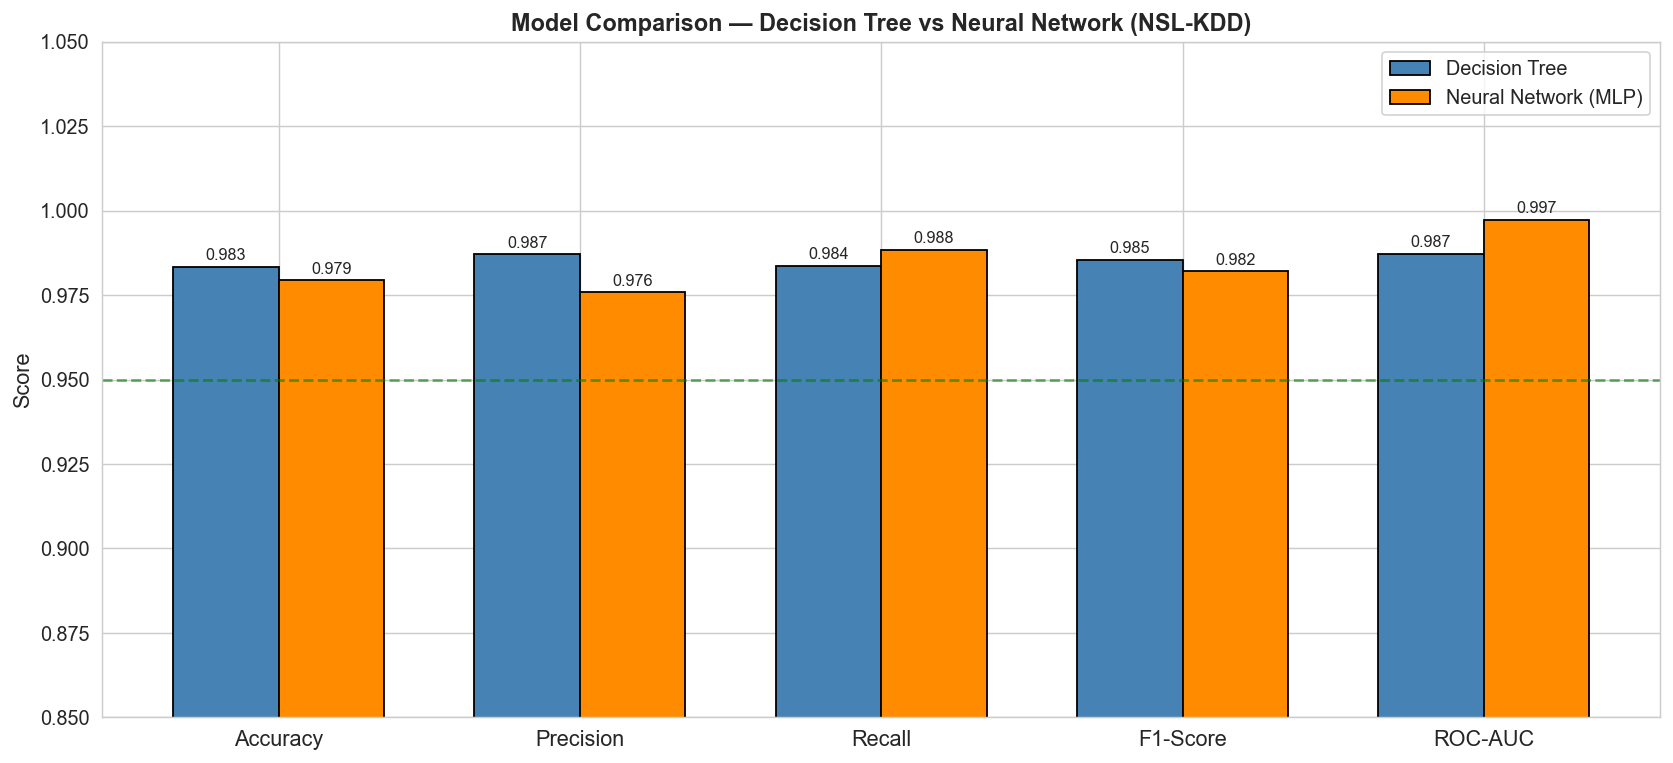

In [17]:
#Model Performance Comparison
results = pd.DataFrame({
    'Model'    : ['Decision Tree', 'Neural Network (MLP)'],
    'Accuracy' : [round(acc_dt,4),  round(acc_mlp,4)],
    'Precision': [round(prec_dt,4), round(prec_mlp,4)],
    'Recall'   : [round(rec_dt,4),  round(rec_mlp,4)],
    'F1-Score' : [round(f1_dt,4),   round(f1_mlp,4)],
    'ROC-AUC'  : [round(auc_dt,4),  round(auc_mlp,4)],
    'CV F1'    : [round(cv_f1_dt.mean(),4), round(cv_f1_mlp.mean(),4)]
})
print('Performance Comparison Table:')
print(results.to_string(index=False))

metrics  = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']
dt_vals  = [acc_dt, prec_dt, rec_dt, f1_dt, auc_dt]
mlp_vals = [acc_mlp,prec_mlp,rec_mlp,f1_mlp,auc_mlp]

x = np.arange(len(metrics))
width = 0.35
fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x-width/2, dt_vals,  width, label='Decision Tree',        color='steelblue',  edgecolor='black')
b2 = ax.bar(x+width/2, mlp_vals, width, label='Neural Network (MLP)', color='darkorange', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0.85, 1.05)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison — Decision Tree vs Neural Network (NSL-KDD)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.axhline(y=0.95, color='green', linestyle='--', alpha=0.6, label='Target 0.95')
for b in list(b1)+list(b2):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.002,
            f'{b.get_height():.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()

### Feature Importance Comparison — DT vs MLP (Permutation)

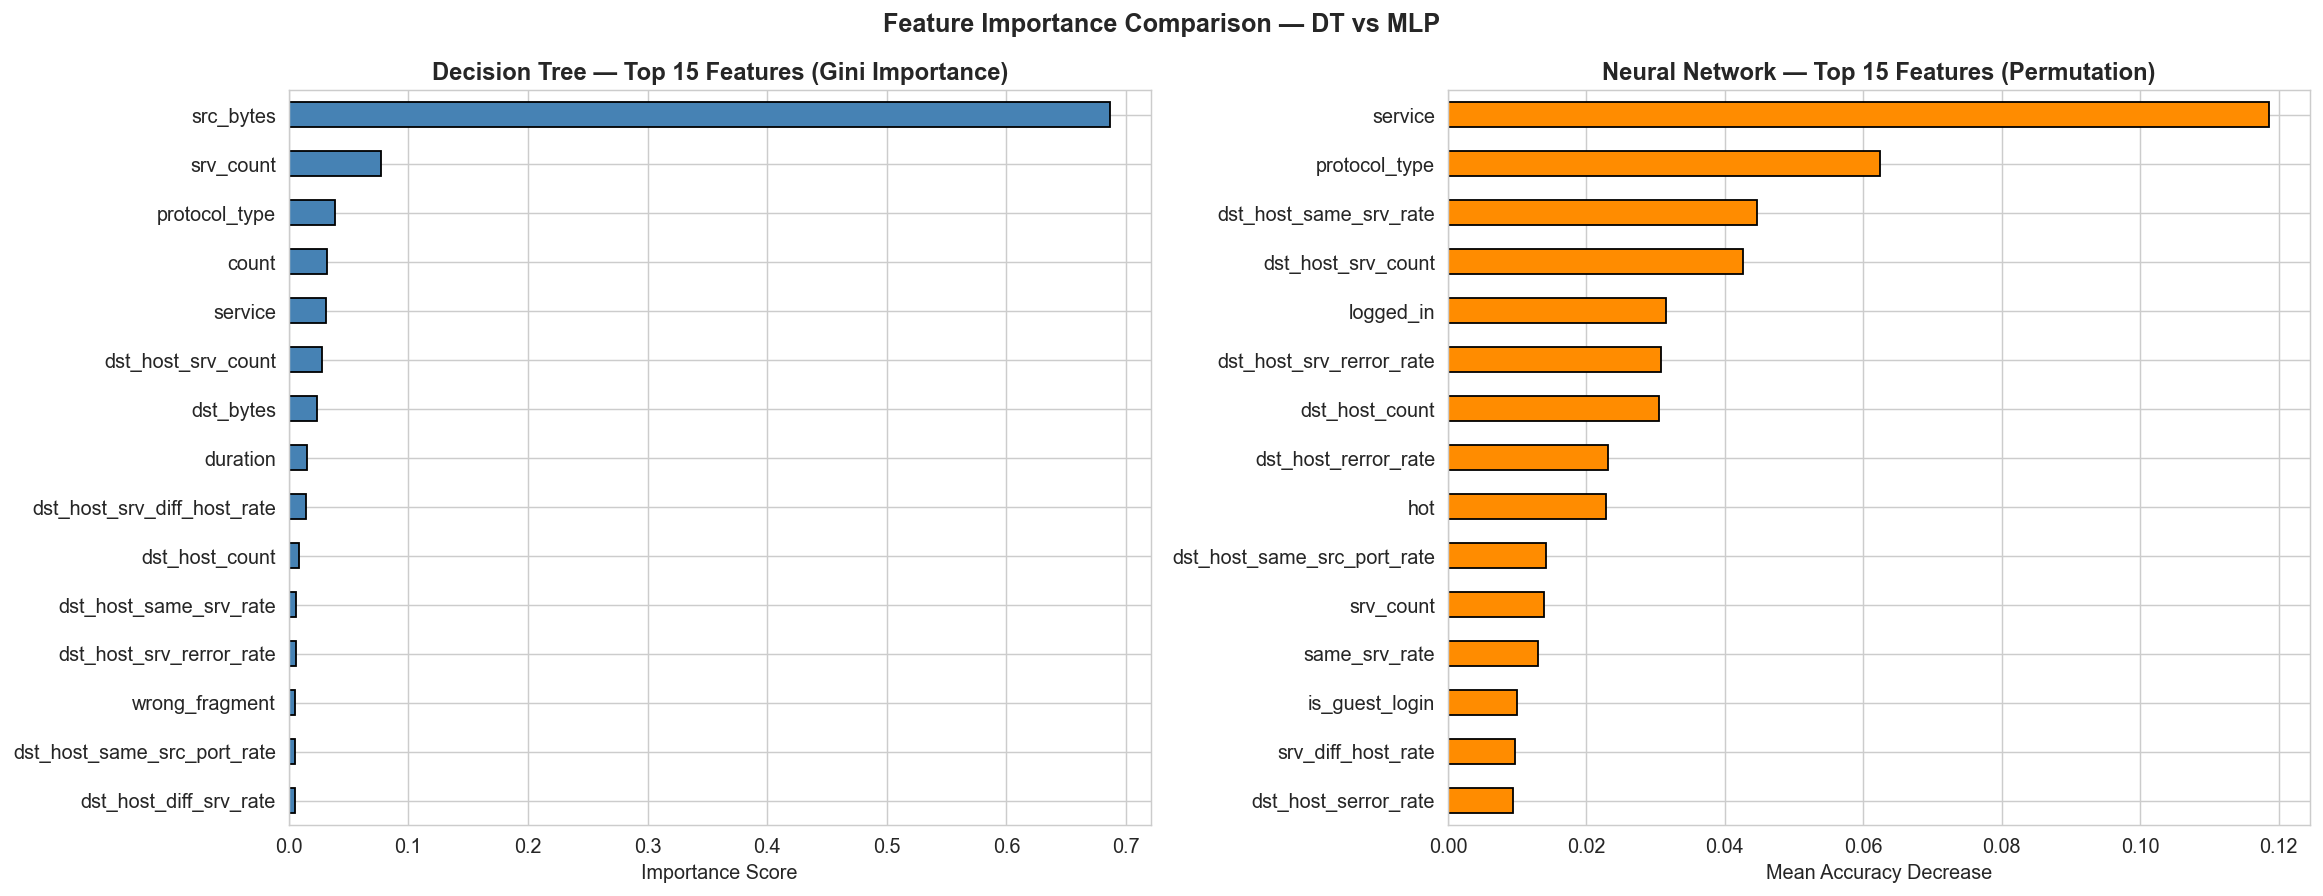

In [18]:
#Feature Importance Comparison — DT vs MLP
# MLP: permutation (model-agnostic)
perm = permutation_importance(mlp_best, X_test, y_test,
                               n_repeats=10, random_state=42, scoring='accuracy')
importances_mlp = pd.Series(perm.importances_mean,
                             index=X.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

importances_dt.head(15).plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Decision Tree — Top 15 Features (Gini Importance)', fontweight='bold')
axes[0].set_xlabel('Importance Score')
axes[0].invert_yaxis()

importances_mlp.head(15).plot(kind='barh', ax=axes[1], color='darkorange', edgecolor='black')
axes[1].set_title('Neural Network — Top 15 Features (Permutation)', fontweight='bold')
axes[1].set_xlabel('Mean Accuracy Decrease')
axes[1].invert_yaxis()

plt.suptitle('Feature Importance Comparison — DT vs MLP', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance_comparison.png', bbox_inches='tight')
plt.show()

### Statistical Significance Test — McNemar's Test

In [19]:
#Statistical Significance Test — McNemar's Test

correct_dt  = (y_pred_dt  == y_test.values)
correct_mlp = (y_pred_mlp == y_test.values)

b = np.sum( correct_dt & ~correct_mlp)
c = np.sum(~correct_dt &  correct_mlp)

contingency = np.array([
    [np.sum(correct_dt  & correct_mlp),  b],
    [c, np.sum(~correct_dt & ~correct_mlp)]
])

result_mc = mcnemar(contingency, exact=False, correction=True)

print('McNemar Statistical Significance Test')
print(f'Statistic : {result_mc.statistic:.4f}')
print(f'p-value   : {result_mc.pvalue:.6f}')
if result_mc.pvalue < 0.05:
    better = 'Neural Network (MLP)' if acc_mlp > acc_dt else 'Decision Tree'
    print(f'Result    : SIGNIFICANT difference (p < 0.05) — {better} is superior.')
else:
    print('Result    : No significant difference between models (p >= 0.05)')

McNemar Statistical Significance Test
Statistic : 2.2578
p-value   : 0.132942
Result    : No significant difference between models (p >= 0.05)


---
## Phase 6 — Deployment Summary (CRISP-DM)

In [20]:
#Deployment Summary (CRISP-DM)
print('=' * 65)
print(' DATASET 2 — NSL-KDD INTRUSION DETECTION — FINAL SUMMARY')
print('=' * 65)
print(f' Dataset       : NSL-KDD Network Intrusion Detection (Kaggle)')
print(f' Records       : 22,544 | Features: 41')
print(f' Target        : class — Normal (0) vs Anomaly/Attack (1)')
print(f' Task          : Binary Classification')
print(f' Train/Test    : 80% / 20% stratified | CV: 5-Fold Stratified')
print()
print(f' Decision Tree :')
print(f'   Accuracy={acc_dt:.4f} | Precision={prec_dt:.4f}')
print(f'   Recall={rec_dt:.4f}   | F1={f1_dt:.4f} | AUC={auc_dt:.4f}')
print()
print(f' Neural Network (MLP):')
print(f'   Accuracy={acc_mlp:.4f} | Precision={prec_mlp:.4f}')
print(f'   Recall={rec_mlp:.4f}   | F1={f1_mlp:.4f} | AUC={auc_mlp:.4f}')
print()
print(f' McNemar p-value : {result_mc.pvalue:.6f}')
print()
print(' V2X Insight: dst_host_srv_count, flag, logged_in, and')
print(' same_srv_rate are the strongest attack discriminators —')
print(' directly observable in V2X RSU/OBU network monitors.')
print('=' * 65)

 DATASET 2 — NSL-KDD INTRUSION DETECTION — FINAL SUMMARY
 Dataset       : NSL-KDD Network Intrusion Detection (Kaggle)
 Records       : 22,544 | Features: 41
 Target        : class — Normal (0) vs Anomaly/Attack (1)
 Task          : Binary Classification
 Train/Test    : 80% / 20% stratified | CV: 5-Fold Stratified

 Decision Tree :
   Accuracy=0.9834 | Precision=0.9871
   Recall=0.9836   | F1=0.9854 | AUC=0.9873

 Neural Network (MLP):
   Accuracy=0.9794 | Precision=0.9758
   Recall=0.9883   | F1=0.9820 | AUC=0.9973

 McNemar p-value : 0.132942

 V2X Insight: dst_host_srv_count, flag, logged_in, and
 same_srv_rate are the strongest attack discriminators —
 directly observable in V2X RSU/OBU network monitors.
